# Dataset Preparation

In [1]:
import pickle
import torch

class WubiCharTokenizer:
    """
    Tokenizes Chinese text into sequences of atomic Wubi symbols (letters + separator).
    Each character becomes a fixed number of tokens (its Wubi code letters + separator).
    No merging across characters occurs.
    """
    def __init__(self, wubi_dict_path):
        with open(wubi_dict_path, 'rb') as f:
            self.ch2wubi = pickle.load(f)

        # Build vocabulary: all possible letters + separator
        self.sep = '#'
        letters = set()
        for code in self.ch2wubi.values():
            letters.update(code)
        # Also include digits? Original mapping strips digits, so just letters.
        self.vocab = ['[PAD]', '[UNK]', self.sep] + sorted(letters)
        self.stoi = {s: i for i, s in enumerate(self.vocab)}
        self.itos = {i: s for s, i in self.stoi.items()}

    def encode(self, text):
        """
        Convert text to a list of token IDs and a list of character spans.
        Returns:
            ids: list of int (token IDs)
            char_spans: list of (start, end) token indices for each character
        """
        text = text.lower()
        ids = []
        char_spans = []
        for ch in text:
            # Get Wubi code (fallback to character itself)
            code = self.ch2wubi.get(ch, ch)
            # Convert each symbol in the code to an ID
            code_ids = [self.stoi.get(c, self.stoi['[UNK]']) for c in code]
            start = len(ids)
            ids.extend(code_ids)
            ids.append(self.stoi[self.sep])
            end = len(ids)
            char_spans.append((start, end))
        return ids, char_spans

    def decode(self, ids):
        """For debugging: convert IDs back to string."""
        return ''.join(self.itos[i] for i in ids if i != self.stoi[self.sep])

In [2]:
# Load the Wubi mapping (from the SubCharTokenization repo)
wubi_dict = ""
wubi_tokenizer = WubiCharTokenizer(wubi_dict)

text = "我是最高的学生"
ids, spans = wubi_tokenizer.encode(text)

print("Token IDs:", ids)
print("Character spans:", spans)
# Output: spans like [(0,5), (5,8), (8,15), ...] depending on code lengths

Token IDs: [29, 2, 22, 2, 22, 14, 2, 37, 25, 2, 30, 2, 21, 28, 2, 32, 19, 2]
Character spans: [(0, 2), (2, 4), (4, 7), (7, 10), (10, 12), (12, 15), (15, 18)]


In [3]:
# Inverse mapping from Wubi to Character
with open("", 'rb') as f:
    wubi2ch = pickle.load(f)

## Pinyin Mapper

In [4]:
INITIALS = [
    "", "b","p","m","f","d","t","n","l","g","k","h",
    "j","q","x","zh","ch","sh","r","z","c","s"
]

FINALS = [
    "a","ai","an","ang","ao","e","ei","en","eng","er",
    "i","ia","ian","iang","iao","ie","in","ing","iong","iu",
    "o","ong","ou",
    "u","ua","uai","uan","uang","ui","un","uo",
    "v","ve","van","vn"
]

TONES = ["1","2","3","4","5"]

ZERO_INITIAL_MAP = {
    "yi":"i", "ya":"ia", "yao":"iao", "ye":"ie", "you":"iu",
    "yan":"ian", "yin":"in", "yang":"iang", "ying":"ing", "yong":"iong",
    "yu":"v", "yue":"ve", "yuan":"van", "yun":"vn",
    "wu":"u", "wa":"ua", "wo":"uo", "wai":"uai", "wei":"ui",
    "wan":"uan", "wen":"un", "wang":"uang", "weng":"ong",
}

JQX_MAPPING = {
    "u": "v",
    "ue": "ve",
    "uan": "van",
    "un": "vn",
}

def normalize_zero_initial(base):
    return ZERO_INITIAL_MAP.get(base, base)

def normalize_jqx(final):
    return JQX_MAPPING.get(final, final)

def denormalize_jqx(final):
    # reverse mapping
    reverse_map = {v: k for k, v in JQX_MAPPING.items()}
    return reverse_map.get(final, final)

ZERO_INITIAL_REVERSE = {v: k for k, v in ZERO_INITIAL_MAP.items()}

init2idx = {v:i for i,v in enumerate(INITIALS)}
final2idx = {v:i for i,v in enumerate(FINALS)}
tone2idx = {v:i for i,v in enumerate(TONES)}

idx2init = {i:v for v,i in init2idx.items()}
idx2final = {i:v for v,i in final2idx.items()}
idx2tone = {i:v for v,i in tone2idx.items()}

def decompose_pinyin(token: str):
    tone = token[-1]
    if not tone.isdigit():
        tone = "5"
        base = token
    else:
        base = token[:-1]

    base = normalize_zero_initial(base)

    for ini in sorted(INITIALS, key=len, reverse=True):
        if base.startswith(ini):
            final = base[len(ini):]
            if ini in {"j","q","x"}:
                final = normalize_jqx(final)
            return [init2idx[ini], final2idx[final], tone2idx[tone]]
    raise ValueError("Invalid pinyin token")

def idx_to_pinyin(init_idx: int, final_idx: int, tone_idx: int) -> str:
    init = idx2init[init_idx]
    fin  = idx2final[final_idx]
    tone = idx2tone[tone_idx]

    if init == "":
        base = ZERO_INITIAL_REVERSE.get(fin, fin)
    else:
        if init in {"j","q","x"}:
            fin = denormalize_jqx(fin)
        base = init + fin

    if tone == "5":
        return base
    else:
        return base + tone

## Dataset: Text + Pinyin

In [5]:
import pandas as pd

dataset = pd.read_csv("")

In [6]:
dataset.head()

,text,pinyin
0,他赢了布什说我很高兴是他赢了,ta1 ying2 le bu4 shen2 shuo1 wo3 hen3 gao1 xin...
1,你根本想不到有多畅销赛义德说,ni3 gen1 ben3 xiang3 bu4 dao4 you3 duo1 chang4...
2,国家主席是个虚职实权掌握在共产党总书记的手里,guo2 jia1 zhu3 xi2 shi4 ge4 xu1 zhi2 shi2 quan...
3,如果你批评以色列政府有些人会因此说你是反犹主义者,ru2 guo3 ni3 pi1 ping2 yi3 se4 lie4 zheng4 fu3...
4,我是一十六号下次请还要叫我啊,wo3 shi4 yi1 shi2 liu4 hao4 xia4 ci4 qing3 hai...


## Dataset: Pinyin Embeddings

In [7]:
import pickle as pkl

with open("", "rb") as f:
    embedding_map = pkl.load(f)

In [8]:
embedding_map['wo3'].shape

(1024,)

### PCA of Phonetic Space

In [9]:
import numpy as np


tokens = list(embedding_map.keys())
X = np.stack([embedding_map[t] for t in tokens])   # shape (n_samples, n_features)
print(f"Matrix shape: {X.shape}")

Matrix shape: (1102, 1024)


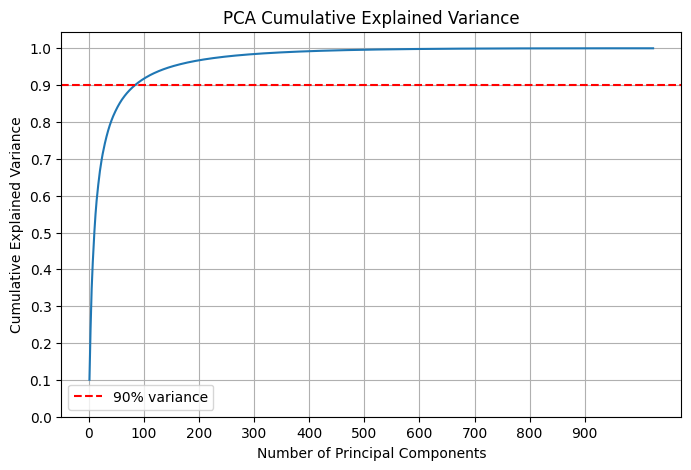

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
X_pca = pca.fit_transform(X)   # optional, if you need components
explained_var = pca.explained_variance_ratio_
cumulative = np.cumsum(explained_var)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative)+1), cumulative)
plt.xticks(np.arange(0, 1000, 100))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
K = 100   # number of components to keep
pca = PCA(n_components=K)
X_reduced = pca.fit_transform(X)   # shape (n_samples, K)
print(f"Reduced shape: {X_reduced.shape}")
print(f"Explained variance ratio (first {K}): {pca.explained_variance_ratio_.sum():.4f}")

Reduced shape: (1102, 100)
Explained variance ratio (first 100): 0.9176


## Dataset: Semantic Embeddings

### BERT Base Chinese

The BERT Base is chosen as the encoder for semantic representations, the tokenizer is per-

In [12]:
from transformers import AutoTokenizer, AutoModel
import torch

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
bert_model = AutoModel.from_pretrained("bert-base-chinese")

sentence = "你好世界"
inputs = bert_tokenizer(sentence, return_tensors="pt")
with torch.no_grad():
    outputs = bert_model(**inputs)
    # last_hidden_state: (1, seq_len, hidden_dim)
    char_embeddings = outputs.last_hidden_state[0]  # remove batch

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
def get_char_embeddings(bert_model, bert_tokenzier, sentence):
    inputs = bert_tokenzier(sentence, return_tensors="pt")
    with torch.no_grad():
        outputs = bert_model(**inputs)
    # Remove [CLS] and [SEP] tokens
    token_embs = outputs.last_hidden_state[0, 1:-1]  # (num_chars, hidden_dim)
    chars = list(sentence)
    return {ch: vec.cpu().numpy() for ch, vec in zip(chars, token_embs)}

In [14]:
for ch, vec in get_char_embeddings(bert_model, bert_tokenizer, '你好世界').items():
    print(ch, vec.shape, vec[:2])

你 (768,) [ 0.2058782 -0.3735184]
好 (768,) [0.48449567 0.08005352]
世 (768,) [0.17610227 0.0756098 ]
界 (768,) [ 0.06911832 -0.44401836]


## Evaluation Dataset

### Filtration

In [15]:
def align(token):
    if token[-1].isalpha():  # e.g. de -> de5
        return token + '5'
    return token

# To see filtered values
dataset[
    dataset['pinyin'].str.split().transform(lambda x: any(align(y) not in embedding_map.keys() for y in x))
]

,text,pinyin
72,纽约时报突尼斯总统贝吉卡伊德埃塞卜西去世享年九十二岁,niu3 yue1 shi2 bao4 tu1 ni2 si1 zong3 tong3 be...
1570,如果我们不能把货运进来就会变得更贵甚至可能要关门售卖黄瓜萝卜和西红柿的小贩左启超音说,ru2 guo3 wo3 men bu4 neng2 ba3 huo4 yun4 jin4 ...
1730,尽管卜蜂莲花与物美善意地进行了广泛的磋商但仍无法就敲定交易中的若干主要条款取得充分进展,jin4 guan3 bo feng1 lian2 hua1 yu3 wu4 mei3 sh...
3301,奥马尔阿卜杜勒拉赫曼可以进世界上任何一个球队踢球阿吉雷,ao4 ma3 er3 a1 bo du4 lei1 la1 he4 man4 ke3 yi...
3549,五年来我一直在照看一小片土地种植玉簪百合落新妇温柔地呵护着一丛绣球花将它挽留在这片土地,wu3 nian2 lai2 wo3 yi1 zhi2 zai4 zhao4 kan4 yi...
...,...,...
167401,苦恼于这些被损毁的建筑也得益于社交网络卜冲高虹以及其他一些本地市民集结起来致力于保护哈尔滨还...,ku3 nao3 yu2 zhe4 xie1 bei4 sun3 hui3 de jian4...
169399,试图保护哈尔滨历史建筑的当地居民左起女商人高虹建筑教授卜冲建筑师餐厅老板胡泓,shi4 tu2 bao3 hu4 ha1 er3 bin1 li4 shi3 jian4 ...
170307,课讲到兴头她常常将故事或箴言中的经验教训信手拈来应用于分析与点评,ke4 jiang3 dao4 xing1 tou2 ji2 chang2 chang2 j...
170318,谁敢在老城区里做这么大的动作在哈尔滨江边的一家咖啡馆里卜冲质疑为什么高铁不能经过哈尔滨城市中...,shui2 gan3 zai4 lao3 cheng2 qu1 li3 zuo4 zhe4 ...


In [16]:
# Actual filtration
dataset = dataset[
    dataset['pinyin'].str.split().transform(lambda x: all(align(y) in embedding_map.keys() for y in x))
]

In [17]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 181197 entries, 0 to 181301
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    181197 non-null  object
 1   pinyin  181197 non-null  object
dtypes: object(2)
memory usage: 4.1+ MB


In [18]:
import re
import pandas as pd

# Unicode range for CJK Unified Ideographs (basic)
# 4E00–9FFF (common), also extensions if needed
hanzi_pattern = re.compile(r'[\u4e00-\u9fff]')

def get_non_hanzi(df):
    """
    Returns a set of all non‑Hanzi characters in the 'text' column.
    """
    non_hanzi = set()
    for text in df['text'].dropna():
        for ch in text:
            if not hanzi_pattern.match(ch):
                non_hanzi.add(ch)
    return non_hanzi

non_hanzi_set = get_non_hanzi(dataset)
print(f"Unique non‑Hanzi characters: {len(non_hanzi_set)}")
print(sorted(non_hanzi_set))

Unique non‑Hanzi characters: 0
[]


In [19]:
# To see filtered values
dataset[
    dataset['text'].transform(lambda x: any(y in non_hanzi_set for y in x))
]

,text,pinyin


In [20]:
# Actual filtration
dataset = dataset[
    dataset['text'].transform(lambda x: all(y not in non_hanzi_set for y in x))
]

In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 181197 entries, 0 to 181301
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    181197 non-null  object
 1   pinyin  181197 non-null  object
dtypes: object(2)
memory usage: 4.1+ MB


### Pinyin Embeddings

In [22]:
import numpy as np
import torch

all_pinyin_tokens = list(embedding_map.keys())

pinyin2idx = {tok: i for i, tok in enumerate(all_pinyin_tokens)}
idx2pinyin = {i: tok for tok, i in pinyin2idx.items()}
embedding_matrix = torch.tensor(X_reduced, dtype=torch.float32)

embedding_matrix.shape

torch.Size([1102, 100])

In [23]:
def get_acoustic_embeddings(padded_pinyin_idxs, embedding_matrix, device, pad_idx=-100):
    """
    Returns acoustic embeddings for each character from a pre‑computed matrix.
    Args:
        padded_pinyin_idxs: (batch, max_chars) indices into embedding_matrix (padded with pad_idx)
        embedding_matrix: (num_tokens, emb_dim) tensor on device
        device: torch device
        pad_idx: padding value
    Returns:
        acoustic_embeddings: (batch, max_chars, emb_dim) – zero vectors for padded positions
    """
    mask = (padded_pinyin_idxs != pad_idx)
    valid_idxs = padded_pinyin_idxs[mask]
    valid_embs = embedding_matrix[valid_idxs]
    batch_size, max_chars = padded_pinyin_idxs.shape
    emb_dim = embedding_matrix.shape[1]
    out = torch.zeros(batch_size, max_chars, emb_dim, device=device)
    out[mask] = valid_embs
    return out

### Semantic Embeddings

In [24]:
def get_bert_embeddings(input_ids, attention_mask, bert_model, device):
    """
    Returns BERT's last hidden states for the given input_ids and attention_mask.
    Args:
        input_ids: (batch, max_seq_len) token IDs (already padded, on device)
        attention_mask: (batch, max_seq_len) attention mask (on device)
        bert_model: BertModel instance
        device: torch device
    Returns:
        hidden_states: (batch, max_seq_len, hidden_dim)
    """
    with torch.no_grad():
        outputs = bert_model(input_ids, attention_mask=attention_mask)
    return outputs.last_hidden_state

### Tokenization

In [25]:
import torch
from torch.utils.data import Dataset
from transformers import BertTokenizer
from tqdm import tqdm

def prepare_bert_dataset(df, tokenizer, wubi_tokenizer, decompose_pinyin, pinyin2idx, align, max_length=512):
    """
    Prepares a dataset for BERT fine‑tuning on pinyin prediction, including Wubi token sets and character strings.
    """
    input_ids_list = []
    attention_mask_list = []
    pinyin_components_list = []
    pinyin_idxs_list = []
    wubi_sets_list = []
    chars_list = []          # list of list of characters (strings)

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Tokenizing"):
        text = row['text']
        pinyin_str = row['pinyin']

        encoding = tokenizer(
            text,
            max_length=max_length,
            truncation=True,
            return_offsets_mapping=True,
            padding=False,
            return_tensors=None
        )
        input_ids = encoding['input_ids']
        attention_mask = encoding['attention_mask']
        offset_mapping = encoding['offset_mapping']

        filtered_input_ids = []
        filtered_attention_mask = []
        char_sequence = []
        for i, (start, end) in enumerate(offset_mapping):
            if start == 0 and end == 0:
                continue
            ch = text[start:start+1]
            char_sequence.append(ch)
            filtered_input_ids.append(input_ids[i])
            filtered_attention_mask.append(attention_mask[i])

        if len(filtered_input_ids) != len(text):
            print(f"Skipping sample {idx}: token count mismatch")
            continue

        pinyin_tokens = pinyin_str.split()
        if len(pinyin_tokens) != len(text):
            print(f"Skipping sample {idx}: pinyin token count mismatch")
            continue

        pinyin_comps = []
        pinyin_idxs_sample = []
        wubi_sets_sample = []
        skip = False
        for i, (ch, py) in enumerate(zip(char_sequence, pinyin_tokens)):
            wubi_ids, _ = wubi_tokenizer.encode(ch)
            if hasattr(wubi_tokenizer, 'sep'):
                sep_ids, _ = wubi_tokenizer.encode(wubi_tokenizer.sep)
                if sep_ids:
                    wubi_set = set(wubi_ids) - {sep_ids[0]}
                else:
                    wubi_set = set(wubi_ids)
            else:
                wubi_set = set(wubi_ids)
            wubi_sets_sample.append(wubi_set)

            try:
                comp = decompose_pinyin(py)
                pinyin_comps.append(comp)
                pinyin_idxs_sample.append(pinyin2idx[align(py)])
            except Exception as e:
                print(f"Skipping sample {idx}: pinyin error {py} - {e}")
                skip = True
                break

        if skip:
            continue

        input_ids_list.append(filtered_input_ids)
        attention_mask_list.append(filtered_attention_mask)
        pinyin_components_list.append(pinyin_comps)
        pinyin_idxs_list.append(pinyin_idxs_sample)
        wubi_sets_list.append(wubi_sets_sample)
        chars_list.append(char_sequence)   # store the characters

    return {
        'input_ids': input_ids_list,
        'attention_mask': attention_mask_list,
        'pinyin_components': pinyin_components_list,
        'pinyin_idxs': pinyin_idxs_list,
        'wubi_sets': wubi_sets_list,
        'chars': chars_list
    }

In [26]:
class BERTPinyinDataset(Dataset):
    def __init__(self, data_dict):
        self.input_ids = data_dict['input_ids']
        self.attention_mask = data_dict['attention_mask']
        self.pinyin_components = data_dict['pinyin_components']
        self.pinyin_idxs = data_dict['pinyin_idxs']
        self.wubi_sets = data_dict['wubi_sets']
        self.chars = data_dict['chars']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.attention_mask[idx], dtype=torch.long),
            'pinyin_components': torch.tensor(self.pinyin_components[idx], dtype=torch.long),
            'pinyin_idxs': torch.tensor(self.pinyin_idxs[idx], dtype=torch.long),
            'wubi_sets': self.wubi_sets[idx],
            'chars': self.chars[idx]
        }

In [27]:
tokenizer = BertTokenizer.from_pretrained("bert-base-chinese")

In [28]:
data = prepare_bert_dataset(dataset, tokenizer, wubi_tokenizer, decompose_pinyin, pinyin2idx, align)
dataset = BERTPinyinDataset(data)

Tokenizing: 100%|██████████| 181197/181197 [01:37<00:00, 1859.90it/s]


In [29]:
for x in dataset:
    print(x.keys())

    print(x['input_ids'].shape, x['pinyin_components'][..., 0].shape)
    break

dict_keys(['input_ids', 'attention_mask', 'pinyin_components', 'pinyin_idxs', 'wubi_sets', 'chars'])
torch.Size([14]) torch.Size([14])


### Complete Dataset

In [30]:
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch

def collate_fn_bert(batch, pad_idx_components=-100):
    input_ids = [item['input_ids'] for item in batch]
    attention_masks = [item['attention_mask'] for item in batch]
    pinyin_comp = [item['pinyin_components'] for item in batch]
    pinyin_idxs = [item['pinyin_idxs'] for item in batch]
    wubi_sets = [item['wubi_sets'] for item in batch]
    chars_list = [item['chars'] for item in batch]

    input_ids_padded = nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=0)
    attention_mask_padded = nn.utils.rnn.pad_sequence(attention_masks, batch_first=True, padding_value=0)
    pinyin_comp_padded = nn.utils.rnn.pad_sequence(pinyin_comp, batch_first=True, padding_value=pad_idx_components)
    pinyin_idxs_padded = nn.utils.rnn.pad_sequence(pinyin_idxs, batch_first=True, padding_value=pad_idx_components)

    char_lengths = torch.tensor([len(seq) for seq in pinyin_comp], dtype=torch.long)

    return (input_ids_padded, attention_mask_padded, pinyin_comp_padded,
            pinyin_idxs_padded, char_lengths, wubi_sets, chars_list)

In [31]:
BATCH_SIZE = 32
PAD_IDX = -100

eval_loader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=lambda b: collate_fn_bert(b, PAD_IDX)
)

# Model Preparation

## Encoder Architecture

In [32]:
from transformers import BertModel, BertTokenizer
import torch
import torch.nn as nn

# Device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Load BERT tokenizer and model
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-chinese")
bert_model = BertModel.from_pretrained("bert-base-chinese")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
import torch.nn as nn

class ClassifierHead(nn.Module):
    """MLP with one hidden layer for classification."""
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class BertPinyinEncoder(nn.Module):
    def __init__(self, bert_model, num_initials, num_finals, num_tones, mlp_hidden_dim=256, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.initial_head  = ClassifierHead(768, mlp_hidden_dim, num_initials, dropout)
        self.final_head    = ClassifierHead(768, mlp_hidden_dim, num_finals, dropout)
        self.tone_head     = ClassifierHead(768, mlp_hidden_dim, num_tones, dropout)
        self.phonetic_head = ClassifierHead(768, mlp_hidden_dim, 1024, dropout)

    def forward(self, input_ids, attention_mask, return_hidden=False):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state   # (batch, seq_len, 768)
        logits_i = self.initial_head(hidden)
        logits_f = self.final_head(hidden)
        logits_t = self.tone_head(hidden)

        if return_hidden:
            phonetic = self.phonetic_head(hidden)
            return logits_i, logits_f, logits_t, phonetic
        return logits_i, logits_f, logits_t

In [34]:
# Instantiate model
num_initials = len(init2idx)
num_finals   = len(final2idx)
num_tones    = len(tone2idx)
encoder = BertPinyinEncoder(bert_model, num_initials, num_finals, num_tones).to(device)

## Loading Model

In [35]:
encoder.load_state_dict(torch.load('', map_location=device))
encoder.eval()

print("Loaded encoder successfully!")

Loaded encoder successfully!


In [36]:
bert_model = bert_model.to(device)

In [37]:
embedding_matrix = embedding_matrix.to(device)

## Hooking Function

In [38]:
def get_hidden_states(input_ids, attention_mask, encoder, device, return_hidden=True):
    """
    Returns hidden states from the BertPinyinEncoder.
    Assumes encoder.forward(input_ids, attention_mask, return_hidden=True) returns
    (logits_i, logits_f, logits_t, hidden).
    Args:
        input_ids: (batch, max_seq_len) token IDs
        attention_mask: (batch, max_seq_len) mask
        encoder: BertPinyinEncoder instance
        device: torch device
    Returns:
        hidden: (batch, max_seq_len, hidden_dim)
    """
    with torch.no_grad():
        *_, hidden = encoder(input_ids, attention_mask, return_hidden=True)
    return hidden

# Extraction

## Basic Loop

In [39]:
for batch in eval_loader:
    input_ids, attention_mask, pinyin_comp, pinyin_idxs, char_lengths, wubi_sets, chars_list = batch

    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)
    pinyin_comp = pinyin_comp.to(device)
    pinyin_idxs = pinyin_idxs.to(device)

    # Get hidden states from the encoder (BertPinyinEncoder)
    hidden_states = get_hidden_states(input_ids, attention_mask, encoder, device)  # (batch, max_seq_len, 768)

    # Get acoustic embeddings (using pinyin_idxs)
    acoustic_embs = get_acoustic_embeddings(pinyin_idxs, embedding_matrix, device, pad_idx=-100)  # (batch, max_seq_len, emb_dim)

    semantic_embs = get_bert_embeddings(input_ids, attention_mask, bert_model, device)

    for b in range(len(chars_list)):
        chars = chars_list[b]
        num_chars = char_lengths[b].item()
        pinyin_components_sample = pinyin_comp[b, :num_chars].cpu().numpy()   # (num_chars, 3)
        wubi_sets_sample = wubi_sets[b]        # list of sets
        # For semantic and hidden, we also slice
        hidden_sample = hidden_states[b, :num_chars].cpu().numpy()
        acoustic_sample = acoustic_embs[b, :num_chars].cpu().numpy()
        semantic_sample = semantic_embs[b, :num_chars].cpu().numpy()

        for i, ch in enumerate(chars[:num_chars]):
            hidden_vec = hidden_sample[i]
            acoustic_vec = acoustic_sample[i]
            semantic_vec = semantic_sample[i]
            wubi_set = wubi_sets_sample[i]
            pinyin_comp_vec = pinyin_components_sample[i]
            print(ch, hidden_vec.shape, acoustic_vec.shape, semantic_vec.shape, wubi_set, pinyin_comp_vec)
            break
        break
    break

他 (1024,) (100,) (768,) {35, 14} [6 0 0]


## Aggregation Over Contexts

In [40]:
# from collections import defaultdict
# import numpy as np
# from tqdm import tqdm

# # Initialize storage
# aggregated = defaultdict(lambda: {
#     'hidden_sum': None,
#     'semantic_sum': None,
#     'count': 0,
#     'wubi_set': None,
#     'acoustic_vec': None,
#     'pinyin_components': None
# })

# for batch in tqdm(eval_loader, desc="Processing batches"):
#     (flat_tokens, char_offsets, char_lengths, padded_pinyin, chars_list,
#      padded_char_idxs, padded_pinyin_idxs) = batch

#     flat_tokens = flat_tokens.to(device)
#     char_offsets = char_offsets.to(device)
#     char_lengths = char_lengths.to(device)
#     padded_pinyin = padded_pinyin.to(device)
#     padded_pinyin_idxs = padded_pinyin_idxs.to(device)

#     hidden_states = get_hidden_states(flat_tokens, char_offsets, char_lengths, encoder, device)
#     acoustic_embs = get_acoustic_embeddings(padded_pinyin_idxs, embedding_matrix, device, PAD_IDX)
#     semantic_embs = get_bert_embeddings(padded_char_idxs, bert_model, device, PAD_IDX)
#     wubi_sets = get_wubi_token_sets(flat_tokens, char_offsets, char_lengths)

#     for b in range(len(chars_list)):
#         chars = chars_list[b]
#         num_chars = char_lengths[b].item()
#         pinyin_components = padded_pinyin[b, :num_chars].cpu().numpy()
#         wubi_sets_sample = wubi_sets[b]

#         for i in range(num_chars):
#             ch = chars[i]
#             pinyin_idx = padded_pinyin_idxs[b, i].item()
#             pinyin_token = idx2pinyin[pinyin_idx]
#             key = (ch, pinyin_token)

#             agg = aggregated[key]
#             # Update sums
#             if agg['hidden_sum'] is None:
#                 agg['hidden_sum'] = hidden_states[b, i].cpu().numpy()
#                 agg['semantic_sum'] = semantic_embs[b, i].cpu().numpy()
#                 agg['wubi_set'] = wubi_sets_sample[i]
#                 agg['acoustic_vec'] = acoustic_embs[b, i].cpu().numpy()
#                 agg['pinyin_components'] = pinyin_components[i]
#             else:
#                 agg['hidden_sum'] += hidden_states[b, i].cpu().numpy()
#                 agg['semantic_sum'] += semantic_embs[b, i].cpu().numpy()
#             agg['count'] += 1

# # After processing all batches, compute averages
# aggregated_results = {}
# for key, data in tqdm(aggregated.items(), desc="Averaging"):
#     hidden_avg = data['hidden_sum'] / data['count']
#     semantic_avg = data['semantic_sum'] / data['count']
#     aggregated_results[key] = {
#         'hidden': hidden_avg,
#         'semantic': semantic_avg,
#         'wubi_set': data['wubi_set'],
#         'acoustic': data['acoustic_vec'],
#         'pinyin_components': data['pinyin_components'],
#         'count': data['count']
#     }

# print(f"Aggregated {len(aggregated_results)} distinct (character, pinyin) pairs.")

In [41]:
# import joblib

# joblib.dump(aggregated_results, 'aggregated_records.joblib')

## Context Dependent Records

In [42]:
from torch.utils.data import DataLoader, Subset
import random

# Set seed for reproducibility
random.seed(0)

total = len(dataset)
sample_size = 10000
indices = random.sample(range(total), sample_size)
sampled_dataset = Subset(dataset, indices)

BATCH_SIZE = 32
PAD_IDX = -100

sample_eval_loader = DataLoader(
    sampled_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=lambda b: collate_fn_bert(b, PAD_IDX)
)

In [43]:
import numpy as np
from tqdm import tqdm

# Create inverse mapping from embedding index to pinyin string
idx2pinyin = {v: k for k, v in pinyin2idx.items()}

records = []  # list of dicts, one per character occurrence


for batch in tqdm(sample_eval_loader, desc="Extracting representations"):
    input_ids, attention_mask, pinyin_comp, pinyin_idxs, char_lengths, wubi_sets, chars_list = batch

    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)
    pinyin_comp = pinyin_comp.to(device)
    pinyin_idxs = pinyin_idxs.to(device)

    # Get hidden states from the encoder (BertPinyinEncoder)
    hidden_states = get_hidden_states(input_ids, attention_mask, encoder, device)  # (batch, max_seq_len, 768)

    # Get acoustic embeddings (using pinyin_idxs)
    acoustic_embs = get_acoustic_embeddings(pinyin_idxs, embedding_matrix, device, pad_idx=-100)  # (batch, max_seq_len, emb_dim)

    semantic_embs = get_bert_embeddings(input_ids, attention_mask, bert_model, device)

    for b in range(len(chars_list)):
        chars = chars_list[b]
        num_chars = char_lengths[b].item()
        pinyin_components_sample = pinyin_comp[b, :num_chars].cpu().numpy()   # (num_chars, 3)
        wubi_sets_sample = wubi_sets[b]        # list of sets
        # For semantic and hidden, we also slice
        hidden_sample = hidden_states[b, :num_chars].cpu().numpy()
        acoustic_sample = acoustic_embs[b, :num_chars].cpu().numpy()
        semantic_sample = semantic_embs[b, :num_chars].cpu().numpy()

        for i, ch in enumerate(chars[:num_chars]):
            hidden_vec = hidden_sample[i]
            acoustic_vec = acoustic_sample[i]
            semantic_vec = semantic_sample[i]
            wubi_set = wubi_sets_sample[i]
            pinyin_comp_vec = pinyin_components_sample[i]
            pinyin_token = idx_to_pinyin(*pinyin_comp_vec)

            record = {
                'char': ch,
                'pinyin': pinyin_token,
                'hidden': hidden_vec,
                'acoustic': acoustic_vec,
                'semantic': semantic_vec,
                'wubi_set': wubi_set,
                'pinyin_components': pinyin_comp_vec  # [init_idx, final_idx, tone_idx]
            }
            records.append(record)

print(f"Collected {len(records)} character occurrences.")
unique_keys = set((rec['char'], rec['pinyin']) for rec in records)
print(f"Distinct (character, pinyin) pairs: {len(unique_keys)}")

Extracting representations: 100%|██████████| 313/313 [01:09<00:00,  4.52it/s]

Collected 299061 character occurrences.
Distinct (character, pinyin) pairs: 4694


In [44]:
import joblib

joblib.dump(records, 'character_records.joblib')

['character_records.joblib']